# 02 Retrieval Benchmark

Notebook này chỉ đánh giá retrieval. Mục tiêu là hiểu retriever nào lấy context tốt hơn trên frozen RAGAS testset, chưa chọn pipeline cuối cùng.

Score trong notebook này là `retrieval_score`, chỉ dùng retrieval metrics hợp lệ. RAGAS non-LLM context metrics được hiển thị như diagnostic và không tham gia chọn pipeline cuối.


In [1]:
from __future__ import annotations

import gc
import hashlib
import html
import json
import math
import os
import re
import warnings
from collections import defaultdict
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from rank_bm25 import BM25Okapi


def find_project_root() -> Path:
    cwd = Path.cwd()
    if (cwd / "notebooks").exists() and (cwd / "reports").exists():
        return cwd
    if cwd.name == "notebooks":
        return cwd.parent
    return cwd


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data/processed/labor_corpus.jsonl"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
CACHE_DIR = PROJECT_ROOT / ".tmp/eval_cache"
RAGAS_QUESTIONS_JSON = REPORTS_DIR / "ragas_questions.json"
RETRIEVAL_JSON = REPORTS_DIR / "retrieval_evaluation.json"
RETRIEVAL_MD = REPORTS_DIR / "retrieval_evaluation.md"

REPORTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("HF_HOME", str(PROJECT_ROOT / ".hf_cache"))
os.environ.setdefault("SENTENCE_TRANSFORMERS_HOME", str(PROJECT_ROOT / ".hf_cache/sentence_transformers"))

TOP_K = 5
CANDIDATE_K = 40
VECTOR_POOL_K = 300
CROSS_ENCODER_CANDIDATES = 30
EMBEDDING_MODEL = "intfloat/multilingual-e5-small"
CROSS_ENCODER_MODEL = "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1"
EVALUATION_VERSION = "retrieval_diagnostics_v2"

METHODS = [
    "bm25",
    "vector",
    "hybrid",
    "hybrid_rrf",
    "hybrid_rrf_cross_encoder",
    "hybrid_rrf_cross_encoder_mmr",
]

METHOD_LABELS = {
    "bm25": "BM25",
    "vector": "Vector",
    "hybrid": "Hybrid",
    "hybrid_rrf": "Hybrid + RRF",
    "hybrid_rrf_cross_encoder": "Hybrid + RRF + Cross-Encoder",
    "hybrid_rrf_cross_encoder_mmr": "Hybrid + RRF + Cross-Encoder + MMR",
}


@dataclass
class LegalDocument:
    id: str
    title: str | None = None
    so_ky_hieu: str | None = None
    ngay_ban_hanh: str | None = None
    loai_van_ban: str | None = None
    ngay_co_hieu_luc: str | None = None
    ngay_het_hieu_luc: str | None = None
    nguon_thu_thap: str | None = None
    ngay_dang_cong_bao: str | None = None
    nganh: str | None = None
    linh_vuc: str | None = None
    co_quan_ban_hanh: str | None = None
    chuc_danh: str | None = None
    nguoi_ky: str | None = None
    pham_vi: str | None = None
    thong_tin_ap_dung: str | None = None
    tinh_trang_hieu_luc: str | None = None
    content_html: str | None = None
    content_text: str | None = None
    source_url: str | None = None
    raw_metadata: dict[str, Any] = field(default_factory=dict)


@dataclass
class LegalChunk:
    chunk_id: str
    doc_id: str
    title: str
    text: str
    article: str | None = None
    source_url: str | None = None
    doc_type: str | None = None
    effective_date: str | None = None
    metadata: dict[str, Any] = field(default_factory=dict)


@dataclass
class SearchResult:
    chunk: LegalChunk
    score: float
    method: str
    rank: int


def sanitize(value):
    if isinstance(value, dict):
        return {key: sanitize(item) for key, item in value.items()}
    if isinstance(value, list):
        return [sanitize(item) for item in value]
    if isinstance(value, tuple):
        return [sanitize(item) for item in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        if math.isnan(float(value)):
            return None
        return float(value)
    if pd.isna(value) if not isinstance(value, (str, bytes, dict, list, tuple)) else False:
        return None
    return value


def normalize_text(text: str | None) -> str:
    text = html.unescape(text or "")
    text = re.sub(r"<script.*?</script>", " ", text, flags=re.DOTALL | re.IGNORECASE)
    text = re.sub(r"<style.*?</style>", " ", text, flags=re.DOTALL | re.IGNORECASE)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def normalize_for_match(text: str | None) -> str:
    return normalize_text(text).lower()


def tokenize_vi(text: str | None) -> list[str]:
    return re.findall(r"\w+", normalize_for_match(text))


ARTICLE_PATTERN = re.compile(r"(?=(?:Điều|ĐIỀU|Äiá»u|ÄIá»€U)\s+\d+[a-zA-Z]?\.)")


def split_by_article_or_window(text: str, max_words: int = 260, overlap: int = 40) -> list[tuple[str | None, str]]:
    text = normalize_text(text)
    if not text:
        return []
    parts = [part.strip() for part in ARTICLE_PATTERN.split(text) if part.strip()]
    if len(parts) > 1:
        chunks = []
        for part in parts:
            match = re.match(r"((?:Điều|Äiá»u)\s+\d+[a-zA-Z]?)\.", part, flags=re.IGNORECASE)
            chunks.append((match.group(1) if match else None, part))
        return chunks
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = min(start + max_words, len(words))
        chunks.append((None, " ".join(words[start:end])))
        if end == len(words):
            break
        start = max(0, end - overlap)
    return chunks


def load_documents(path: Path) -> list[LegalDocument]:
    documents = []
    with path.open(encoding="utf-8") as handle:
        for line in handle:
            if line.strip():
                documents.append(LegalDocument(**json.loads(line)))
    return documents


def chunk_document(document: LegalDocument, max_words: int = 260, overlap: int = 40) -> list[LegalChunk]:
    source_text = document.content_text or document.content_html or ""
    chunks = []
    for idx, (article, text) in enumerate(split_by_article_or_window(source_text, max_words, overlap)):
        if len(text.split()) < 30:
            continue
        chunks.append(
            LegalChunk(
                chunk_id=f"{document.id}_{idx}",
                doc_id=document.id,
                title=document.title or "",
                text=text,
                article=article,
                source_url=document.source_url,
                doc_type=document.loai_van_ban,
                effective_date=document.ngay_co_hieu_luc,
                metadata={
                    "so_ky_hieu": document.so_ky_hieu,
                    "agency": document.co_quan_ban_hanh,
                    "status": document.tinh_trang_hieu_luc,
                },
            )
        )
    return chunks


def chunk_documents(documents: list[LegalDocument]) -> list[LegalChunk]:
    chunks = []
    for document in documents:
        chunks.extend(chunk_document(document))
    return chunks


def load_questions() -> tuple[dict, list[dict]]:
    payload = json.loads(RAGAS_QUESTIONS_JSON.read_text(encoding="utf-8"))
    if not payload.get("generated_with_ragas"):
        raise ValueError("reports/ragas_questions.json must come from RAGAS TestsetGenerator.")
    items = payload.get("items", [])
    if len(items) < 30:
        raise ValueError("RAGAS benchmark must contain at least 30 accepted questions.")
    return payload, items


## 1. Benchmark Inputs

Load the frozen RAGAS-generated questions and rebuild chunks from the labor-law corpus. The notebook keeps this standalone so it remains a research artifact, not app code.


In [2]:
question_meta, questions = load_questions()
documents = load_documents(DATA_PATH)
chunks = chunk_documents(documents)
document_count = len(documents)
del documents
gc.collect()

display(pd.DataFrame([{
    "questions": len(questions),
    "documents": document_count,
    "chunks": len(chunks),
    "top_k": TOP_K,
    "candidate_k": CANDIDATE_K,
}]))
display(pd.DataFrame([{key: question_meta.get(key) for key in ["generated_with_ragas", "candidate_target", "accepted_count"]}]))


,questions,documents,chunks,top_k,candidate_k
0,30,17379,128519,5,40


,generated_with_ragas,candidate_target,accepted_count
0,True,40,30


## 2. Retrieval Methods

### BM25
Keyword baseline. Strong when the legal question contains exact terms such as contract, dismissal, salary, or insurance.

### Vector
Dense semantic retrieval with `intfloat/multilingual-e5-small` and FAISS over a broad per-query candidate pool. This keeps the full-corpus notebook runnable while still testing semantic reranking.

### Hybrid
Weighted BM25 + vector score. This is the simple mixed baseline.

### Hybrid + RRF
Rank fusion between BM25 and vector. This reduces sensitivity to score scale differences.

### Hybrid + RRF + Cross-Encoder
RRF candidate generation followed by local Cross-Encoder reranking. This tests whether a stronger query-context scorer improves top results.

### Hybrid + RRF + Cross-Encoder + MMR
Cross-Encoder reranking followed by MMR diversity. This checks whether reducing redundant contexts helps downstream answer quality.


In [3]:
def chunk_text(chunk: LegalChunk) -> str:
    return f"{chunk.title} {chunk.article or ''} {chunk.text}".strip()


def embedding_text(chunk: LegalChunk, max_words: int = 120) -> str:
    words = chunk.text.split()[:max_words]
    return f"{chunk.title} {chunk.article or ''} {' '.join(words)}".strip()


def minmax(results: list[SearchResult]) -> dict[str, float]:
    if not results:
        return {}
    scores = [result.score for result in results]
    low, high = min(scores), max(scores)
    if high == low:
        return {result.chunk.chunk_id: 1.0 for result in results}
    return {result.chunk.chunk_id: (result.score - low) / (high - low) for result in results}


class DenseEncoder:
    def __init__(self, model_name: str):
        self.model_name = model_name
        self.model = None

    def _model_instance(self):
        if self.model is None:
            from sentence_transformers import SentenceTransformer
            self.model = SentenceTransformer(self.model_name, cache_folder=str(PROJECT_ROOT / ".hf_cache"))
            self.model.max_seq_length = 128
        return self.model

    def encode_passages(self, texts: list[str]) -> np.ndarray:
        if not texts:
            return np.zeros((0, 384), dtype="float32")
        model = self._model_instance()
        return model.encode(
            [f"passage: {text}" for text in texts],
            batch_size=64,
            normalize_embeddings=True,
            convert_to_numpy=True,
            show_progress_bar=False,
        ).astype("float32")

    def encode_query(self, query: str) -> np.ndarray:
        model = self._model_instance()
        return model.encode(
            [f"query: {query}"],
            normalize_embeddings=True,
            convert_to_numpy=True,
            show_progress_bar=False,
        ).astype("float32")


class ResearchRetriever:
    def __init__(self, chunks: list[LegalChunk]):
        self.chunks = chunks
        self.chunk_by_id = {chunk.chunk_id: chunk for chunk in chunks}
        self.index_by_chunk_id = {chunk.chunk_id: idx for idx, chunk in enumerate(chunks)}
        self.query_cache: dict[str, np.ndarray] = {}
        self.base_cache: dict[str, tuple[list[SearchResult], list[SearchResult]]] = {}
        self.rrf_cache: dict[str, list[SearchResult]] = {}
        self.cross_cache: dict[str, list[SearchResult]] = {}
        self.pool_embedding_cache: dict[str, dict[str, np.ndarray]] = {}
        self.bm25 = BM25Okapi([tokenize_vi(chunk_text(chunk)) for chunk in chunks])
        self.encoder = DenseEncoder(EMBEDDING_MODEL)
        self.cross_encoder = None

    def retrieve(self, query: str, method: str, top_k: int = TOP_K) -> list[SearchResult]:
        sparse, vector = self.base_results(query, top_k)
        if method == "bm25":
            return self._rerank(sparse[:top_k], "bm25")
        if method == "vector":
            return self._rerank(vector[:top_k], "vector")
        if method == "hybrid":
            return self.weighted_hybrid(sparse, vector, top_k)
        rrf_results = self.rrf_results(query, sparse, vector, top_k)
        if method == "hybrid_rrf":
            return self._rerank(rrf_results[:top_k], "hybrid_rrf")
        cross_results = self.cross_results(query, rrf_results)
        if method == "hybrid_rrf_cross_encoder":
            return self._rerank(cross_results[:top_k], "hybrid_rrf_cross_encoder")
        if method == "hybrid_rrf_cross_encoder_mmr":
            return self.mmr(query, cross_results, top_k)
        raise ValueError(f"Unknown method: {method}")

    def base_results(self, query: str, top_k: int) -> tuple[list[SearchResult], list[SearchResult]]:
        if query not in self.base_cache:
            candidate_k = min(len(self.chunks), max(CANDIDATE_K, top_k * 8))
            sparse_pool_k = min(len(self.chunks), max(VECTOR_POOL_K, candidate_k))
            sparse_pool = self.retrieve_bm25(query, sparse_pool_k)
            self.base_cache[query] = (
                sparse_pool[:candidate_k],
                self.retrieve_vector(query, sparse_pool, candidate_k),
            )
        return self.base_cache[query]

    def rrf_results(self, query: str, sparse: list[SearchResult], vector: list[SearchResult], top_k: int) -> list[SearchResult]:
        if query not in self.rrf_cache:
            candidate_k = min(len(self.chunks), max(CANDIDATE_K, top_k * 8))
            self.rrf_cache[query] = self.rrf([sparse, vector], candidate_k)
        return self.rrf_cache[query]

    def cross_results(self, query: str, rrf_results: list[SearchResult]) -> list[SearchResult]:
        if query not in self.cross_cache:
            self.cross_cache[query] = self.cross_encoder_rerank(
                query,
                rrf_results[:CROSS_ENCODER_CANDIDATES],
                top_k=CROSS_ENCODER_CANDIDATES,
            )
        return self.cross_cache[query]

    def _rerank(self, results: list[SearchResult], method: str) -> list[SearchResult]:
        return [SearchResult(result.chunk, float(result.score), method, rank) for rank, result in enumerate(results, start=1)]

    def retrieve_bm25(self, query: str, top_k: int) -> list[SearchResult]:
        scores = self.bm25.get_scores(tokenize_vi(query))
        indices = sorted(range(len(scores)), key=lambda idx: scores[idx], reverse=True)[:top_k]
        return [SearchResult(self.chunks[int(idx)], float(scores[int(idx)]), "bm25", rank) for rank, idx in enumerate(indices, start=1)]

    def retrieve_vector(self, query: str, candidates: list[SearchResult], top_k: int) -> list[SearchResult]:
        import faiss

        if not candidates:
            return []
        embeddings = self.encoder.encode_passages([embedding_text(result.chunk) for result in candidates])
        self.pool_embedding_cache[query] = {
            result.chunk.chunk_id: embeddings[idx]
            for idx, result in enumerate(candidates)
        }
        index = faiss.IndexFlatIP(embeddings.shape[1])
        index.add(embeddings)
        scores, indices = index.search(self.encode_query(query), min(top_k, len(candidates)))
        return [
            SearchResult(candidates[int(idx)].chunk, float(score), "vector", rank)
            for rank, (idx, score) in enumerate(zip(indices[0], scores[0]), start=1)
            if idx >= 0
        ]

    def encode_query(self, query: str) -> np.ndarray:
        if query not in self.query_cache:
            self.query_cache[query] = self.encoder.encode_query(query)
        return self.query_cache[query]

    def weighted_hybrid(self, sparse: list[SearchResult], vector: list[SearchResult], top_k: int) -> list[SearchResult]:
        sparse_scores = minmax(sparse)
        vector_scores = minmax(vector)
        scores = defaultdict(float)
        for chunk_id, score in sparse_scores.items():
            scores[chunk_id] += 0.55 * score
        for chunk_id, score in vector_scores.items():
            scores[chunk_id] += 0.45 * score
        ordered = sorted(scores.items(), key=lambda item: item[1], reverse=True)[:top_k]
        return [SearchResult(self.chunk_by_id[chunk_id], float(score), "hybrid", rank) for rank, (chunk_id, score) in enumerate(ordered, start=1)]

    def rrf(self, result_lists: list[list[SearchResult]], top_k: int, k: int = 60) -> list[SearchResult]:
        scores = defaultdict(float)
        for results in result_lists:
            for rank, result in enumerate(results, start=1):
                scores[result.chunk.chunk_id] += 1.0 / (k + rank)
        ordered = sorted(scores.items(), key=lambda item: item[1], reverse=True)[:top_k]
        return [SearchResult(self.chunk_by_id[chunk_id], float(score), "hybrid_rrf", rank) for rank, (chunk_id, score) in enumerate(ordered, start=1)]

    def _cross_encoder_instance(self):
        if self.cross_encoder is None:
            self.encoder.model = None
            gc.collect()
            from sentence_transformers import CrossEncoder
            self.cross_encoder = CrossEncoder(CROSS_ENCODER_MODEL, max_length=512)
        return self.cross_encoder

    def cross_encoder_rerank(self, query: str, candidates: list[SearchResult], top_k: int) -> list[SearchResult]:
        if not candidates:
            return []
        model = self._cross_encoder_instance()
        pairs = [(query, chunk_text(result.chunk)) for result in candidates]
        scores = np.asarray(model.predict(pairs, batch_size=16, show_progress_bar=False), dtype="float32")
        ranked = sorted(zip(candidates, scores), key=lambda item: float(item[1]), reverse=True)[:top_k]
        return [SearchResult(result.chunk, float(score), "hybrid_rrf_cross_encoder", rank) for rank, (result, score) in enumerate(ranked, start=1)]

    def mmr(self, query: str, candidates: list[SearchResult], top_k: int, lambda_mult: float = 0.75) -> list[SearchResult]:
        if not candidates:
            return []
        query_vec = self.encode_query(query)[0]
        relevance = minmax(candidates)
        selected: list[SearchResult] = []
        remaining = candidates[:]
        while remaining and len(selected) < top_k:
            best_idx, best_score = 0, -float("inf")
            for idx, result in enumerate(remaining):
                candidate_vec = self.embedding_for(query, result.chunk)
                diversity_penalty = 0.0
                if selected:
                    selected_vecs = np.asarray([self.embedding_for(query, item.chunk) for item in selected], dtype="float32")
                    diversity_penalty = float(np.max(selected_vecs @ candidate_vec))
                query_similarity = float(candidate_vec @ query_vec)
                score = lambda_mult * max(relevance.get(result.chunk.chunk_id, 0.0), query_similarity) - (1 - lambda_mult) * diversity_penalty
                if score > best_score:
                    best_idx, best_score = idx, score
            chosen = remaining.pop(best_idx)
            selected.append(SearchResult(chosen.chunk, float(best_score), "hybrid_rrf_cross_encoder_mmr", len(selected) + 1))
        return selected

    def embedding_for(self, query: str, chunk: LegalChunk) -> np.ndarray:
        pool = self.pool_embedding_cache.setdefault(query, {})
        if chunk.chunk_id not in pool:
            pool[chunk.chunk_id] = self.encoder.encode_passages([embedding_text(chunk)])[0]
        return pool[chunk.chunk_id]


retriever = ResearchRetriever(chunks)
for item in questions:
    retriever.encode_query(item["question"])
retriever.encoder.model = None
gc.collect()
display(Markdown(f"Loaded retriever with dense model `{EMBEDDING_MODEL}` and cross-encoder `{CROSS_ENCODER_MODEL}`."))


C:\Users\Acer Nitro\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3490.28it/s]

Loaded retriever with dense model `intfloat/multilingual-e5-small` and cross-encoder `cross-encoder/mmarco-mMiniLMv2-L12-H384-v1`.

## 3. Retrieval Metrics

The main ranking score below uses only retrieval metrics that are always measured in this notebook. RAGAS context metrics are kept as diagnostic columns.


In [4]:
def content_tokens(text: str | None) -> set[str]:
    return {token for token in tokenize_vi(text) if len(token) > 1}


def overlap_score(result: SearchResult, item: dict) -> float:
    expected = content_tokens(f"{item.get('question', '')} {item.get('reference', '')}")
    actual = content_tokens(chunk_text(result.chunk))
    if not expected or not actual:
        return 0.0
    return len(expected & actual) / len(expected)


def local_metrics(results: list[SearchResult], item: dict) -> dict[str, float]:
    gains = [overlap_score(result, item) for result in results]
    first_match = next((idx for idx, gain in enumerate(gains, start=1) if gain >= 0.12), None)
    recall = 1.0 if first_match else 0.0
    mrr = 1.0 / first_match if first_match else 0.0
    dcg = sum(gain / math.log2(idx + 2) for idx, gain in enumerate(gains))
    ideal = sum(gain / math.log2(idx + 2) for idx, gain in enumerate(sorted(gains, reverse=True)))
    ndcg = dcg / ideal if ideal else 0.0
    reference_tokens = content_tokens(item.get("reference", ""))
    context_tokens = content_tokens(" ".join(chunk_text(result.chunk) for result in results))
    lexical_precision = len(reference_tokens & context_tokens) / len(context_tokens) if context_tokens else 0.0
    lexical_recall = len(reference_tokens & context_tokens) / len(reference_tokens) if reference_tokens else 0.0
    citation_coverage = sum(1 for result in results if result.chunk.title or result.chunk.source_url) / max(1, len(results))
    return {
        "recall@5": recall,
        "mrr": mrr,
        "ndcg@5": ndcg,
        "lexical_context_precision": lexical_precision,
        "lexical_context_recall": lexical_recall,
        "citation_coverage": citation_coverage,
    }


def serialize_result(result: SearchResult) -> dict:
    return {
        "chunk_id": result.chunk.chunk_id,
        "doc_id": result.chunk.doc_id,
        "title": result.chunk.title,
        "article": result.chunk.article,
        "text": result.chunk.text,
        "source_url": result.chunk.source_url,
        "score": result.score,
        "rank": result.rank,
    }


def retrieval_score(row: dict) -> float:
    return (
        0.30 * row["recall@5"]
        + 0.25 * row["mrr"]
        + 0.25 * row["ndcg@5"]
        + 0.10 * row["lexical_context_precision"]
        + 0.10 * row["lexical_context_recall"]
    )


def ragas_context_scores(rows: list[dict]) -> dict[str, dict[str, float]]:
    try:
        from datasets import Dataset
        from ragas import evaluate
        from ragas.metrics._context_precision import NonLLMContextPrecisionWithReference
        from ragas.metrics._context_recall import NonLLMContextRecall
    except Exception as error:
        warnings.warn(f"RAGAS non-LLM context metrics unavailable: {error}")
        return {}

    scores = {}
    for method in METHODS:
        method_rows = [row for row in rows if row["method"] == method]
        if not method_rows:
            continue
        dataset = Dataset.from_list([
            {
                "user_input": row["question"],
                "retrieved_contexts": row["retrieved_contexts"],
                "reference": row["reference"],
            }
            for row in method_rows
        ])
        try:
            result = evaluate(
                dataset=dataset,
                metrics=[NonLLMContextPrecisionWithReference(), NonLLMContextRecall()],
                show_progress=False,
            )
            frame = result.to_pandas()
            scores[method] = {
                "ragas_context_precision": float(frame["non_llm_context_precision_with_reference"].mean()),
                "ragas_context_recall": float(frame["non_llm_context_recall"].mean()),
            }
        except Exception as error:
            warnings.warn(f"RAGAS context metrics skipped for {method}: {type(error).__name__}")
            scores[method] = {
                "ragas_context_precision": None,
                "ragas_context_recall": None,
            }
    return scores


details, ragas_rows = [], []
for method in METHODS:
    for item in questions:
        results = retriever.retrieve(item["question"], method=method, top_k=TOP_K)
        metrics = local_metrics(results, item)
        row = {
            "question_id": item["id"],
            "question": item["question"],
            "reference": item["reference"],
            "method": method,
            **metrics,
            "results": [serialize_result(result) for result in results],
        }
        details.append(row)
        ragas_rows.append({
            "method": method,
            "question": item["question"],
            "reference": item["reference"],
            "retrieved_contexts": [chunk_text(result.chunk) for result in results],
        })

ragas_scores = ragas_context_scores(ragas_rows)

summary = []
for method in METHODS:
    method_rows = [row for row in details if row["method"] == method]
    aggregate = {
        "method": method,
        "display_name": METHOD_LABELS[method],
        "recall@5": float(np.mean([row["recall@5"] for row in method_rows])),
        "mrr": float(np.mean([row["mrr"] for row in method_rows])),
        "ndcg@5": float(np.mean([row["ndcg@5"] for row in method_rows])),
        "lexical_context_precision": float(np.mean([row["lexical_context_precision"] for row in method_rows])),
        "lexical_context_recall": float(np.mean([row["lexical_context_recall"] for row in method_rows])),
        "citation_coverage": float(np.mean([row["citation_coverage"] for row in method_rows])),
        "ragas_context_precision": ragas_scores.get(method, {}).get("ragas_context_precision"),
        "ragas_context_recall": ragas_scores.get(method, {}).get("ragas_context_recall"),
    }
    aggregate["retrieval_score"] = retrieval_score(aggregate)
    summary.append(aggregate)

summary = sorted(summary, key=lambda row: (row["retrieval_score"], row["mrr"], row["ndcg@5"]), reverse=True)
retrieval_report = {
    "evaluation_version": EVALUATION_VERSION,
    "selection_stage": "retrieval_diagnostics_only",
    "methods": METHODS,
    "method_labels": METHOD_LABELS,
    "question_count": len(questions),
    "benchmark_chunks": len(chunks),
    "top_k": TOP_K,
    "vector_pool_k": VECTOR_POOL_K,
    "embedding_model": EMBEDDING_MODEL,
    "cross_encoder_model": CROSS_ENCODER_MODEL,
    "retrieval_score_formula": "0.30*recall@5 + 0.25*mrr + 0.25*ndcg@5 + 0.10*lexical_context_precision + 0.10*lexical_context_recall",
    "ragas_backend": "ragas_evaluate_non_llm",
    "ragas_context_note": "Diagnostic only; not used in retrieval_score.",
    "summary": summary,
    "details": details,
}
RETRIEVAL_JSON.write_text(json.dumps(sanitize(retrieval_report), ensure_ascii=False, indent=2), encoding="utf-8")

retrieval_df = pd.DataFrame(summary)
display(retrieval_df)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7103.18it/s]

The Transformer `cache_dir` argument is deprecated. Please pass `cache_dir` via `model_kwargs`, `processor_kwargs`, and/or `config_kwargs` instead.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3858.76it/s]

D:\Documents\Project\RAG\vietnamese-legal-rag\.tmp\ipykernel_17424\4249244650.py:94: UserWarning: RAGAS context metrics skipped for bm25: ValueError
  warnings.warn(f"RAGAS context metrics skipped for {method}: {type(error).__name__}")
D:\Documents\Project\RAG\vietnamese-legal-rag\.tmp\ipykernel_17424\4249244650.py:94: UserWarning: RAGAS context metrics skipped for vector: ValueError
  warnings.warn(f"RAGAS context metrics skipped for {method}: {type(error).__name__}")
D:\Documents\Project\RAG\vietnamese-legal-rag\.tmp\ipykernel_17424\4249244650.py:94: UserWarning: RAGAS context metrics skipped for hybrid: ValueError
  warnings.warn(f"RAGAS context metrics skipped for {method}: {type(error).__name__}")
D:\Documents\Project\RAG\vietnamese-legal-rag\.tmp\ipykernel_17424\4249244650.py:94: UserWarning: RAGAS context metrics skipped for hybrid_rrf: ValueError
  warnings.warn(f"RAGAS context metrics skipped for {method}: {type(error).__name__}")
D:\Documents\Project\RAG\vietnamese-legal-rag\

,method,display_name,recall@5,mrr,ndcg@5,lexical_context_precision,lexical_context_recall,citation_coverage,ragas_context_precision,ragas_context_recall,retrieval_score
0,hybrid_rrf_cross_encoder,Hybrid + RRF + Cross-Encoder,1.0,1.000000,0.969921,0.109843,0.910093,1.0,None,None,0.894474
1,hybrid_rrf_cross_encoder_mmr,Hybrid + RRF + Cross-Encoder + MMR,1.0,1.000000,0.970685,0.106036,0.907807,1.0,None,None,0.894056
2,hybrid,Hybrid,1.0,1.000000,0.972680,0.108740,0.888305,1.0,None,None,0.892874
3,hybrid_rrf,Hybrid + RRF,1.0,1.000000,0.957307,0.109208,0.898111,1.0,None,None,0.890059
4,bm25,BM25,1.0,1.000000,0.965627,0.094182,0.883226,1.0,None,None,0.889148
5,vector,Vector,1.0,0.977778,0.960940,0.110490,0.858703,1.0,None,None,0.881599


## 4. Retrieval Figures and Report

The plots below make the retrieval comparison easy to scan for portfolio review.


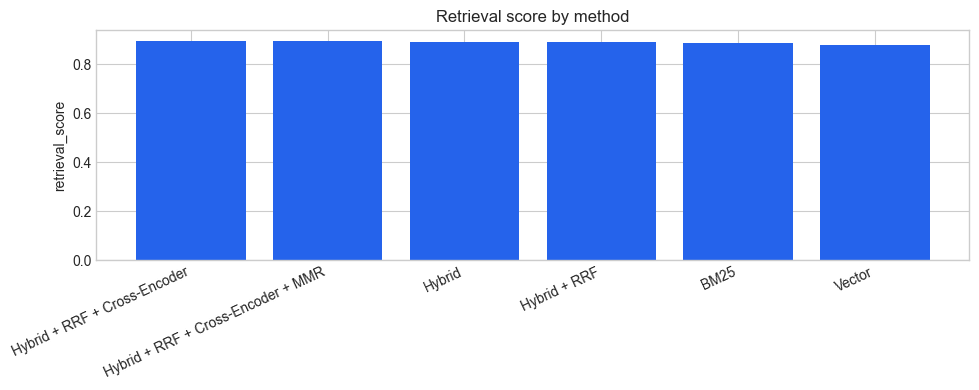

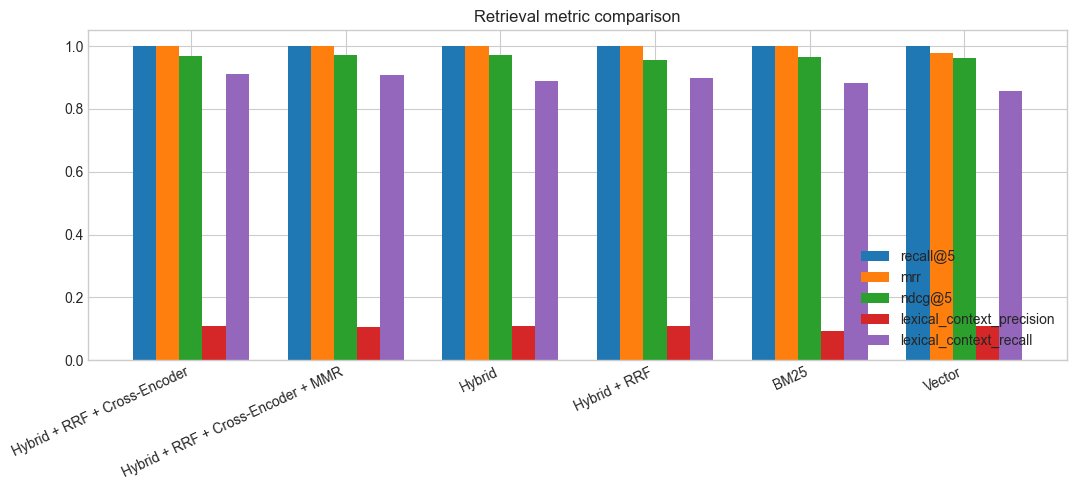

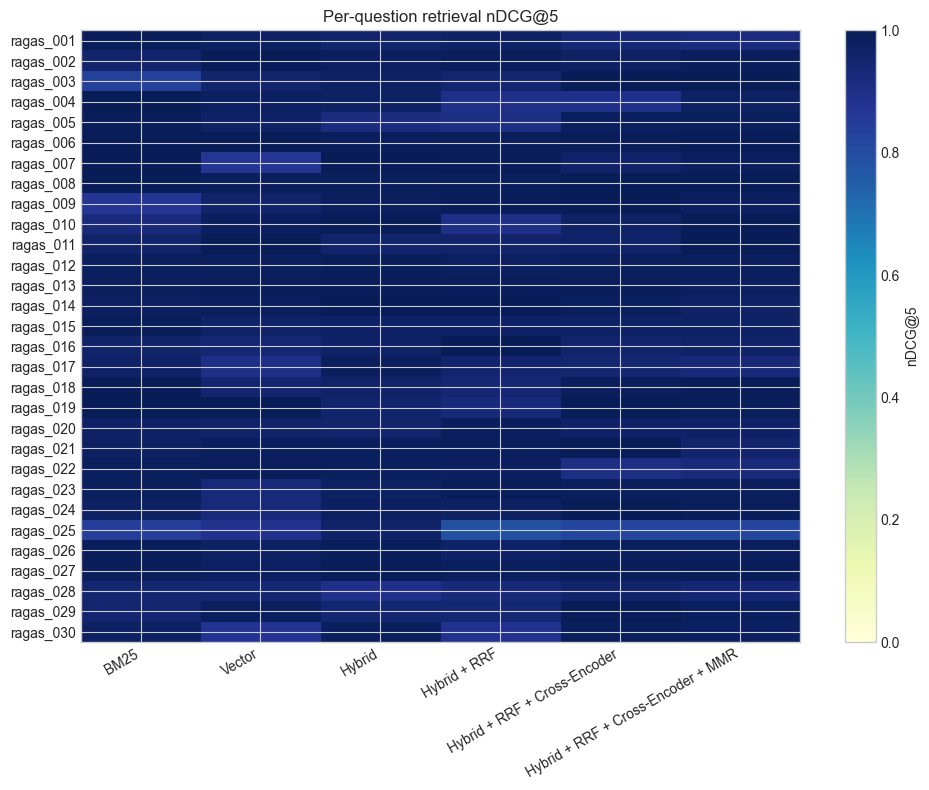

Notebook 02 is retrieval diagnostics only. Final pipeline selection happens in notebook 03.

In [5]:
plt.style.use("seaborn-v0_8-whitegrid")

ordered = retrieval_df.sort_values("retrieval_score", ascending=False)
plt.figure(figsize=(10, 4))
plt.bar(ordered["display_name"], ordered["retrieval_score"], color="#2563eb")
plt.ylabel("retrieval_score")
plt.xticks(rotation=25, ha="right")
plt.title("Retrieval score by method")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "retrieval_score.png", dpi=160)
plt.show()

metric_columns = ["recall@5", "mrr", "ndcg@5", "lexical_context_precision", "lexical_context_recall"]
metric_plot = retrieval_df.set_index("display_name")[metric_columns].loc[ordered["display_name"]]
plt.figure(figsize=(11, 5))
x = np.arange(len(metric_plot.index))
width = 0.15
for idx, metric in enumerate(metric_columns):
    plt.bar(x + idx * width, metric_plot[metric], width=width, label=metric)
plt.xticks(x + width * (len(metric_columns) - 1) / 2, metric_plot.index, rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.title("Retrieval metric comparison")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "retrieval_metric_comparison.png", dpi=160)
plt.show()

detail_df = pd.DataFrame(details)
heat = detail_df.pivot(index="question_id", columns="method", values="ndcg@5").loc[:, METHODS]
plt.figure(figsize=(10, 8))
plt.imshow(heat.values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=1)
plt.colorbar(label="nDCG@5")
plt.xticks(range(len(heat.columns)), [METHOD_LABELS[m] for m in heat.columns], rotation=30, ha="right")
plt.yticks(range(len(heat.index)), heat.index)
plt.title("Per-question retrieval nDCG@5")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "retrieval_query_heatmap.png", dpi=160)
plt.show()

lines = [
    "# Retrieval Evaluation",
    "",
    f"- Question count: `{retrieval_report['question_count']}`",
    f"- Benchmark chunks: `{retrieval_report['benchmark_chunks']}`",
    f"- Selection stage: `{retrieval_report['selection_stage']}`",
    f"- Dense embedding model: `{EMBEDDING_MODEL}`",
    f"- Vector pool size: `{VECTOR_POOL_K}` BM25 candidates per query",
    f"- Cross-Encoder model: `{CROSS_ENCODER_MODEL}`",
    f"- Retrieval score formula: `{retrieval_report['retrieval_score_formula']}`",
    f"- RAGAS context note: `{retrieval_report['ragas_context_note']}`",
    "",
    "| Rank | Method | Recall@5 | MRR | nDCG@5 | Lexical CP | Lexical CR | RAGAS CP | RAGAS CR | Retrieval score |",
    "|---:|---|---:|---:|---:|---:|---:|---:|---:|---:|",
]
for rank, row in enumerate(retrieval_df.to_dict("records"), start=1):
    ragas_cp = "N/A" if row.get("ragas_context_precision") is None else f"{row['ragas_context_precision']:.3f}"
    ragas_cr = "N/A" if row.get("ragas_context_recall") is None else f"{row['ragas_context_recall']:.3f}"
    lines.append(
        f"| {rank} | {row['display_name']} | {row['recall@5']:.3f} | {row['mrr']:.3f} | {row['ndcg@5']:.3f} | "
        f"{row['lexical_context_precision']:.3f} | {row['lexical_context_recall']:.3f} | {ragas_cp} | {ragas_cr} | {row['retrieval_score']:.3f} |"
    )
lines.extend([
    "",
    "## Figures",
    "",
    "- `reports/figures/retrieval_score.png`",
    "- `reports/figures/retrieval_metric_comparison.png`",
    "- `reports/figures/retrieval_query_heatmap.png`",
])
RETRIEVAL_MD.write_text("\n".join(lines) + "\n", encoding="utf-8")
Markdown("Notebook 02 is retrieval diagnostics only. Final pipeline selection happens in notebook 03.")
